# Dataset Trajectory Visualization

This notebook visualizes trajectories from the toy example dataset in phase space, with separate plots for:
1. **Stable trajectories only** - trajectories that converge to equilibrium
2. **Mixed trajectories** - both stable and unstable trajectories for comparison

## 1. Import Required Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# Use tikzplotlib for LaTeX export
import tikzplotlib

# Set plotting style
plt.style.use('default')
%matplotlib inline

## 2. Configuration

Set the path to your dataset and parameters for visualization.

In [28]:
# Dataset configuration
DATA_DIR = Path.home() / "genSecSysId-Data/data/toy_example/prepared"
SPLIT = "test"  # Choose: "train", "validation", or "test"

# Output directory for plots
OUTPUT_DIR = Path.home() / "genSecSysId-Data/plots/toy_example"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Visualization parameters
N_STABLE = 20  # Number of stable trajectories to plot
N_UNSTABLE = 10  # Number of unstable trajectories to plot
STABILITY_THRESHOLD = 1  # Threshold for final state x₂ to classify as stable

print(f"Dataset directory: {DATA_DIR / SPLIT}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Number of stable trajectories: {N_STABLE}")
print(f"Number of unstable trajectories: {N_UNSTABLE}")
print(f"Stability threshold: {STABILITY_THRESHOLD}")

Dataset directory: /Users/jack/genSecSysId-Data/data/toy_example/prepared/test
Output directory: /Users/jack/genSecSysId-Data/plots/toy_example
Number of stable trajectories: 20
Number of unstable trajectories: 10
Stability threshold: 1


## 3. Load Dataset Trajectories

Load all trajectory files and classify them as stable or unstable based on their final state.

In [29]:
def load_trajectories(data_dir, split="test"):
    """Load all trajectory files from the specified split."""
    split_dir = data_dir / split
    trajectory_files = sorted(split_dir.glob("*.csv"))
    
    if len(trajectory_files) == 0:
        raise ValueError(f"No trajectory files found in {split_dir}")
    
    trajectories = []
    for file in tqdm(trajectory_files, desc=f"Loading {split} trajectories"):
        df = pd.read_csv(file)
        trajectories.append({
            'filename': file.name,
            'data': df,
            'x1': df['x_1'].values,
            'x2': df['x_2'].values,
            'd': df['d'].values,
            'time': df['time'].values,
        })
    
    return trajectories


def classify_stability(trajectories, threshold=2):
    """
    Classify trajectories as stable or unstable.
    
    Stable: final state velocity is close to zero (|x_2| < threshold)
    Unstable: final state velocity is large (|x_2| >= threshold)
    """
    stable = []
    unstable = []
    
    for traj in trajectories:
        final_velocity = abs(traj['x2'][-1])
        
        if final_velocity < threshold:
            stable.append(traj)
        else:
            unstable.append(traj)
    
    return stable, unstable


# Load and classify trajectories
all_trajectories = load_trajectories(DATA_DIR, SPLIT)
stable_trajectories, unstable_trajectories = classify_stability(
    all_trajectories, 
    threshold=STABILITY_THRESHOLD
)

print(f"\nTotal trajectories: {len(all_trajectories)}")
print(f"Stable trajectories: {len(stable_trajectories)} ({len(stable_trajectories)/len(all_trajectories)*100:.1f}%)")
print(f"Unstable trajectories: {len(unstable_trajectories)} ({len(unstable_trajectories)/len(all_trajectories)*100:.1f}%)")

Loading test trajectories: 100%|██████████| 270/270 [00:00<00:00, 578.46it/s]


Total trajectories: 270
Stable trajectories: 255 (94.4%)
Unstable trajectories: 15 (5.6%)


## 4. Plot Stable Trajectories Only

Visualize only the stable trajectories in phase space (x₁ vs x₂).

✓ Saved PNG: /Users/jack/genSecSysId-Data/plots/toy_example/phase_space_stable_only.png
✓ Saved TEX: /Users/jack/genSecSysId-Data/plots/toy_example/phase_space_stable_only.tex
  All trajectories converge to equilibrium (|x₂| < 1)


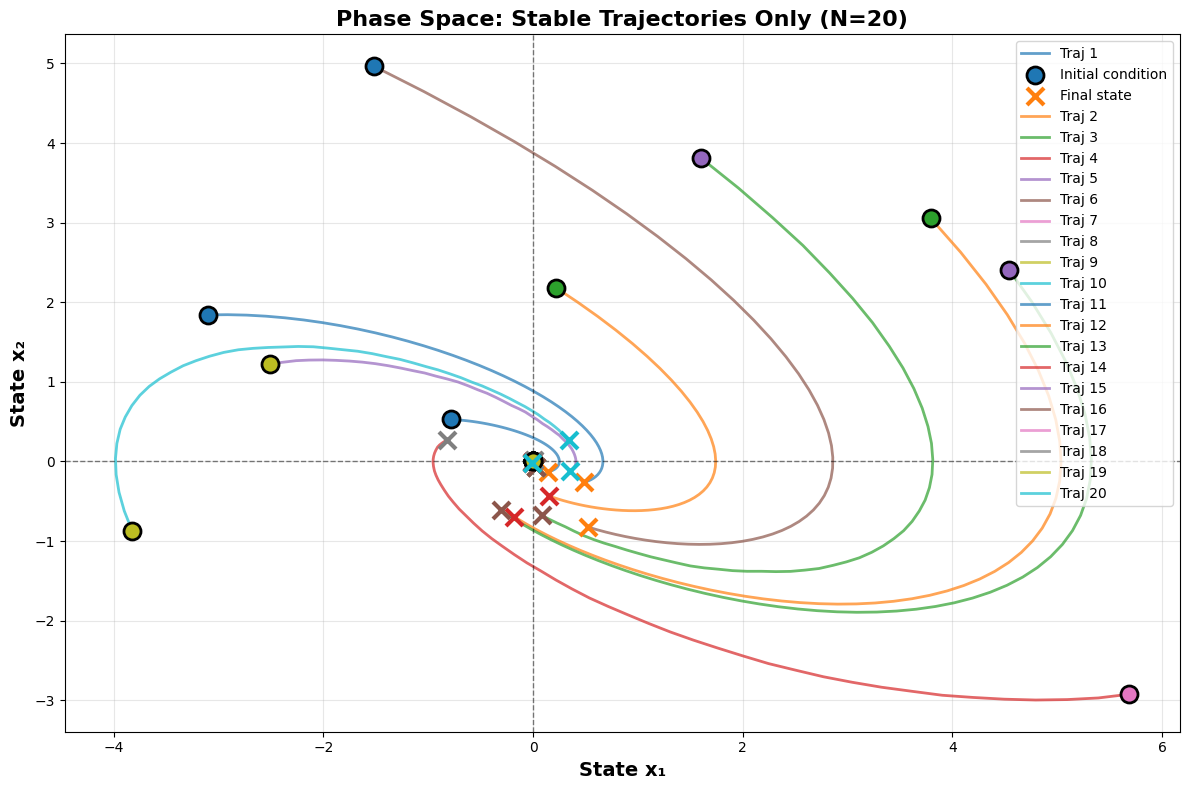


✓ Plotted 20 stable trajectories


In [30]:
# Select random stable trajectories
n_stable_plot = min(N_STABLE, len(stable_trajectories))
stable_indices = np.random.choice(len(stable_trajectories), size=n_stable_plot, replace=False)
selected_stable = [stable_trajectories[i] for i in stable_indices]

# Create phase space plot
fig, ax = plt.subplots(figsize=(12, 8))

for idx, traj in enumerate(selected_stable):
    x1 = traj['x1']
    x2 = traj['x2']
    
    # Plot trajectory
    ax.plot(x1, x2, linewidth=2, alpha=0.7, label=f"Traj {idx+1}")
    
    # Mark start and end points
    if idx == 0:
        ax.scatter(x1[0], x2[0], s=150, marker='o', 
                  edgecolors='black', linewidths=2, zorder=10, label='Initial condition')
        ax.scatter(x1[-1], x2[-1], s=150, marker='x', 
                  linewidths=3, zorder=10, label='Final state')
    else:
        ax.scatter(x1[0], x2[0], s=150, marker='o', 
                  edgecolors='black', linewidths=2, zorder=10)
        ax.scatter(x1[-1], x2[-1], s=150, marker='x', 
                  linewidths=3, zorder=10)

# Formatting
ax.set_xlabel('State x₁', fontsize=14, fontweight='bold')
ax.set_ylabel('State x₂', fontsize=14, fontweight='bold')
ax.set_title(f'Phase Space: Stable Trajectories Only (N={n_stable_plot})', 
            fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1)

# Add legend
ax.legend(loc='best', fontsize=10)

plt.tight_layout()

# Save plot
png_path = OUTPUT_DIR / 'phase_space_stable_only.png'
tex_path = OUTPUT_DIR / 'phase_space_stable_only.tex'
fig.savefig(png_path, dpi=300, bbox_inches='tight')
tikzplotlib.save(tex_path)
print(f"✓ Saved PNG: {png_path}")
print(f"✓ Saved TEX: {tex_path}")

print(f"  All trajectories converge to equilibrium (|x₂| < {STABILITY_THRESHOLD})")

plt.show()
print(f"\n✓ Plotted {n_stable_plot} stable trajectories")


## 5. Plot Mixed Trajectories (Stable + Unstable)

Visualize both stable and unstable trajectories together for comparison.

✓ Saved PNG: /Users/jack/genSecSysId-Data/plots/toy_example/phase_space_mixed.png
✓ Saved TEX: /Users/jack/genSecSysId-Data/plots/toy_example/phase_space_mixed.tex


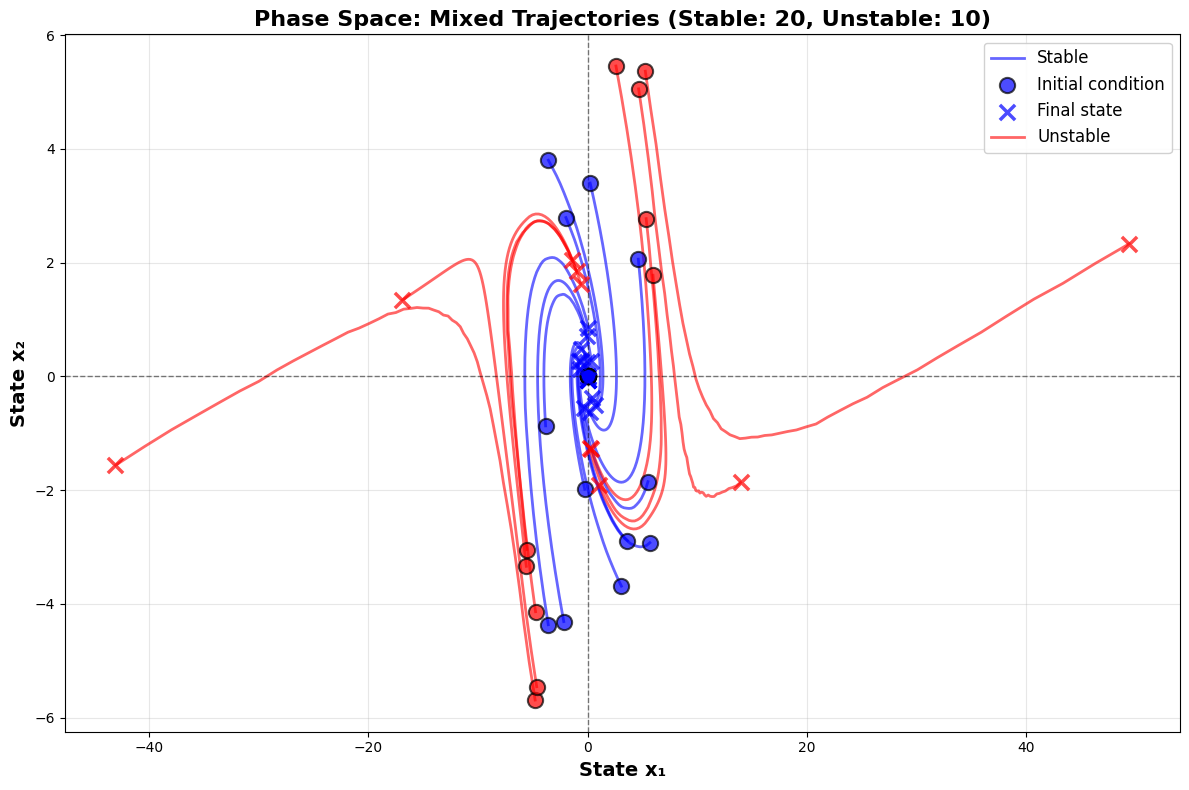

  - Stability criterion: |x₂_final| < 1
  - Unstable (red): 10 trajectories

✓ Plotted 30 trajectories:
  - Stable (blue): 20 trajectories


In [31]:
# Select random trajectories from both categories
n_stable_mixed = min(N_STABLE, len(stable_trajectories))
n_unstable_mixed = min(N_UNSTABLE, len(unstable_trajectories))

stable_indices_mixed = np.random.choice(len(stable_trajectories), size=n_stable_mixed, replace=False)
selected_stable_mixed = [stable_trajectories[i] for i in stable_indices_mixed]

unstable_indices_mixed = np.random.choice(len(unstable_trajectories), size=n_unstable_mixed, replace=False) if len(unstable_trajectories) > 0 else []
selected_unstable_mixed = [unstable_trajectories[i] for i in unstable_indices_mixed] if len(unstable_trajectories) > 0 else []

# Create phase space plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot stable trajectories in blue
for idx, traj in enumerate(selected_stable_mixed):
    x1 = traj['x1']
    x2 = traj['x2']
    
    ax.plot(x1, x2, linewidth=2, alpha=0.6, color='blue',
           label='Stable' if idx == 0 else '')
    
    # Mark start and end points
    if idx == 0:
        ax.scatter(x1[0], x2[0], s=120, marker='o', color='blue',
                  edgecolors='black', linewidths=1.5, zorder=10, alpha=0.7, label='Initial condition')
        ax.scatter(x1[-1], x2[-1], s=120, marker='x', color='blue',
                  linewidths=2.5, zorder=10, alpha=0.7, label='Final state')
    else:
        ax.scatter(x1[0], x2[0], s=120, marker='o', color='blue',
                  edgecolors='black', linewidths=1.5, zorder=10, alpha=0.7)
        ax.scatter(x1[-1], x2[-1], s=120, marker='x', color='blue',
                  linewidths=2.5, zorder=10, alpha=0.7)

# Plot unstable trajectories in red
for idx, traj in enumerate(selected_unstable_mixed):
    x1 = traj['x1']
    x2 = traj['x2']
    
    ax.plot(x1, x2, linewidth=2, alpha=0.6, color='red',
           label='Unstable' if idx == 0 else '')
    
    # Mark start and end points
    ax.scatter(x1[0], x2[0], s=120, marker='o', color='red',
              edgecolors='black', linewidths=1.5, zorder=10, alpha=0.7)
    ax.scatter(x1[-1], x2[-1], s=120, marker='x', color='red',
              linewidths=2.5, zorder=10, alpha=0.7)

# Formatting
ax.set_xlabel('State x₁', fontsize=14, fontweight='bold')
ax.set_ylabel('State x₂', fontsize=14, fontweight='bold')
ax.set_title(f'Phase Space: Mixed Trajectories (Stable: {n_stable_mixed}, Unstable: {n_unstable_mixed})', 
            fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1)

# Add legend
ax.legend(loc='best', fontsize=12, framealpha=0.9)

plt.tight_layout()

# Save plot
png_path = OUTPUT_DIR / 'phase_space_mixed.png'
tex_path = OUTPUT_DIR / 'phase_space_mixed.tex'
fig.savefig(png_path, dpi=300, bbox_inches='tight')
tikzplotlib.save(tex_path)
print(f"✓ Saved PNG: {png_path}")
print(f"✓ Saved TEX: {tex_path}")


plt.show()
print(f"  - Stability criterion: |x₂_final| < {STABILITY_THRESHOLD}")

print(f"  - Unstable (red): {n_unstable_mixed} trajectories")

print(f"\n✓ Plotted {n_stable_mixed + n_unstable_mixed} trajectories:")
print(f"  - Stable (blue): {n_stable_mixed} trajectories")

## 6. Additional Analysis (Optional)

Analyze the distribution of final velocities to understand stability characteristics.

/var/folders/20/k44l3vsj03x1v_37v25mlp4w0000gn/T/ipykernel_6796/3569315001.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, labels=labels, patch_artist=True)


✓ Saved PNG: /Users/jack/genSecSysId-Data/plots/toy_example/stability_analysis.png
✓ Saved TEX: /Users/jack/genSecSysId-Data/plots/toy_example/stability_analysis.tex


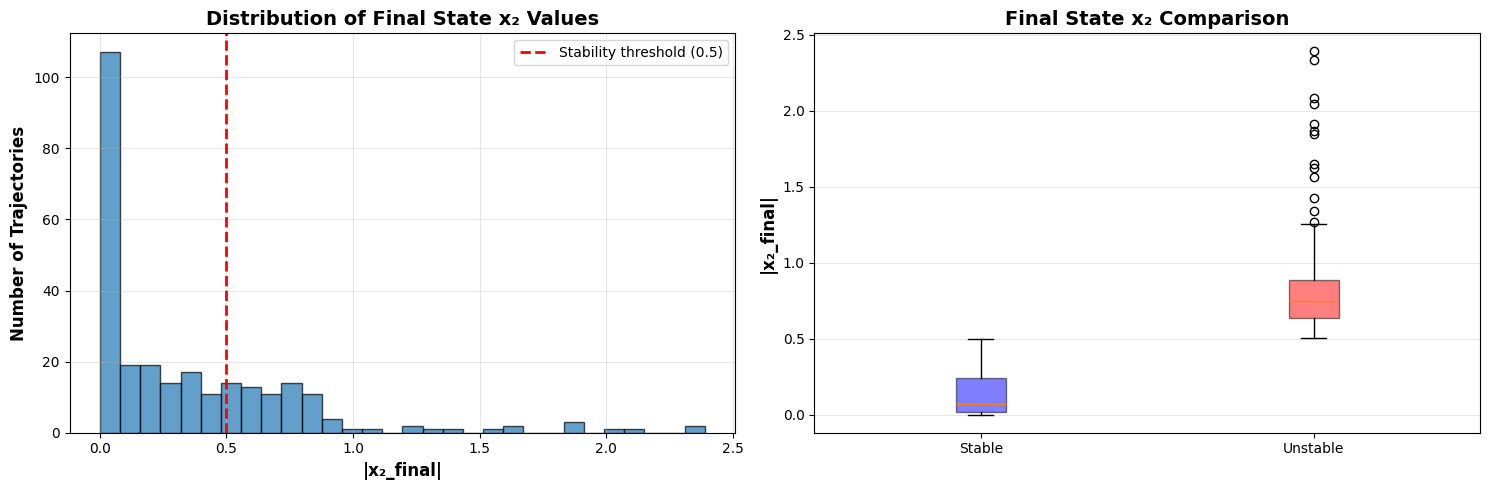


STABILITY STATISTICS
Stable trajectories:
  Mean |x₂_final|: 0.1454
  Std |x₂_final|:  0.1477
  Max |x₂_final|:  0.4999

Unstable trajectories:
  Mean |x₂_final|: 0.9007
  Std |x₂_final|:  0.4462
  Min |x₂_final|:  0.5034


In [11]:
# Analyze final state values
final_velocities = [abs(traj['x2'][-1]) for traj in all_trajectories]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of final state values
ax1 = axes[0]
ax1.hist(final_velocities, bins=30, edgecolor='black', alpha=0.7)
ax1.axvline(x=STABILITY_THRESHOLD, color='red', linestyle='--', linewidth=2, 
           label=f'Stability threshold ({STABILITY_THRESHOLD})')
ax1.set_xlabel('|x₂_final|', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Trajectories', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Final State x₂ Values', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot comparison
ax2 = axes[1]
stable_final_vels = [abs(traj['x2'][-1]) for traj in stable_trajectories]
unstable_final_vels = [abs(traj['x2'][-1]) for traj in unstable_trajectories]

data_to_plot = []
labels = []
if len(stable_final_vels) > 0:
    data_to_plot.append(stable_final_vels)
    labels.append('Stable')
if len(unstable_final_vels) > 0:
    data_to_plot.append(unstable_final_vels)
    labels.append('Unstable')

bp = ax2.boxplot(data_to_plot, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], ['blue', 'red'][:len(data_to_plot)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

ax2.set_ylabel('|x₂_final|', fontsize=12, fontweight='bold')
ax2.set_title('Final State x₂ Comparison', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# Save plot
png_path = OUTPUT_DIR / 'stability_analysis.png'
tex_path = OUTPUT_DIR / 'stability_analysis.tex'
fig.savefig(png_path, dpi=300, bbox_inches='tight')
tikzplotlib.save(tex_path)
print(f"✓ Saved PNG: {png_path}")
print(f"✓ Saved TEX: {tex_path}")

plt.show()

# Print statistics
print("\n" + "="*60)
print("STABILITY STATISTICS")
print("="*60)
print(f"Stable trajectories:")
print(f"  Mean |x₂_final|: {np.mean(stable_final_vels):.4f}")
print(f"  Std |x₂_final|:  {np.std(stable_final_vels):.4f}")
print(f"  Max |x₂_final|:  {np.max(stable_final_vels):.4f}")
if len(unstable_final_vels) > 0:
    print(f"\nUnstable trajectories:")
    print(f"  Mean |x₂_final|: {np.mean(unstable_final_vels):.4f}")
    print(f"  Std |x₂_final|:  {np.std(unstable_final_vels):.4f}")
    print(f"  Min |x₂_final|:  {np.min(unstable_final_vels):.4f}")